# Creating data loaders
### Use features will include punctuation in the dataset while not using them will remove them
### This will enable us to compare whether punctuation features do help

In [4]:
import pandas as pd
import torch
import re
from torch.utils.data import TensorDataset, DataLoader
from transformers import RobertaTokenizerFast
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

def remove_punctuation(text):
    text = re.sub(r'[!?"]', '', text)
    text = re.sub(r'\.\.\.', '', text)
    text = text.lower()
    return text

def loaders(filename, use_features=True, n=25000, batch_size=16, max_length=128, random_state=42):
    df_full = pd.read_csv(filename)
    df = df_full.sample(n=n, random_state=random_state).reset_index(drop=True)

    train_val_df, test_df = train_test_split(df, test_size=0.2, random_state=random_state)
    train_df, val_df = train_test_split(train_val_df, test_size=0.125, random_state=random_state)

    if not use_features:
        train_df = train_df.copy()
        val_df   = val_df.copy()
        test_df  = test_df.copy()
        train_df['comment'] = train_df['comment'].astype(str).apply(remove_punctuation)
        val_df['comment']   = val_df['comment'].astype(str).apply(remove_punctuation)
        test_df['comment']  = test_df['comment'].astype(str).apply(remove_punctuation)

    tokenizer = RobertaTokenizerFast.from_pretrained('roberta-base')

    def encode(split_df):
        return tokenizer(
            split_df['comment'].astype(str).tolist(),
            truncation=True, padding='max_length', max_length=max_length, return_tensors='pt'
        )

    train_encodings = encode(train_df)
    val_encodings   = encode(val_df)
    test_encodings  = encode(test_df)

    train_labels = torch.tensor(train_df['label'].values, dtype=torch.long)
    val_labels   = torch.tensor(val_df['label'].values,   dtype=torch.long)
    test_labels  = torch.tensor(test_df['label'].values,  dtype=torch.long)

    train_feats = torch.zeros(len(train_df), 0)
    val_feats   = torch.zeros(len(val_df),   0)
    test_feats  = torch.zeros(len(test_df),  0)


    def make_loader(encodings, feats, labels, shuffle):
        ds = TensorDataset(encodings['input_ids'], encodings['attention_mask'], feats, labels)
        return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

    train_loader = make_loader(train_encodings, train_feats, train_labels, shuffle=True)
    val_loader   = make_loader(val_encodings,   val_feats,   val_labels,   shuffle=False)
    test_loader  = make_loader(test_encodings,  test_feats,  test_labels,  shuffle=False)

    print(f"[{'with' if use_features else 'without'} features] {filename}")
    print(f"  Train: {len(train_loader)} batches | Val: {len(val_loader)} | Test: {len(test_loader)}\n")

    return train_loader, val_loader, test_loader

# RoBERTa Model

In [5]:
# RoBERTa Model

import torch.nn as nn
from transformers import RobertaModel

class RobertaWithFeatures(nn.Module):
    def __init__(self, num_extra_features, num_classes=2):
        super(RobertaWithFeatures, self).__init__()
        self.roberta = RobertaModel.from_pretrained('roberta-base')

        hidden = self.roberta.config.hidden_size
        combined_dim = hidden + num_extra_features

        self.drop = nn.Dropout(0.3)

        self.classifier = nn.Sequential(
            nn.Linear(combined_dim, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, 128),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )

    def forward(self, input_ids, attention_mask, extra_features):
        output = self.roberta(input_ids=input_ids, attention_mask=attention_mask,
                          output_hidden_states=True)


        hidden_states = output.hidden_states
        last_4 = torch.stack(hidden_states[-4:], dim=0).mean(0)

        mask = attention_mask.unsqueeze(-1).float()
        pooled = (last_4 * mask).sum(1) / mask.sum(1)
        pooled = self.drop(pooled)

        if extra_features.shape[1] > 0:
            combined = torch.cat((pooled, extra_features), dim=1)
        else:
            combined = pooled
        return self.classifier(combined)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Defining Training and Testing Loop Functions

In [6]:
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
import gc
import torch.nn.functional as F


def train_model(model, train_loader, val_loader, model_name="model", epochs=3, lr=5e-6, patience=2):
    optimizer = AdamW([
        {"params": model.roberta.embeddings.parameters(), "lr": 0},
        {"params": model.roberta.encoder.parameters(), "lr": 1e-5},
        {"params": model.classifier.parameters(), "lr": 3e-4},
    ], weight_decay=0.01)
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=100,
        num_training_steps=len(train_loader) * epochs
    )

    train_losses, val_losses, val_accuracies = [], [], []
    best_val_loss = float('inf')
    epochs_no_improve = 0
    save_path = f"best_{model_name}.pt"

    gc.collect()
    torch.cuda.empty_cache()
    print(f"Starting training: {model_name}\n")

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for i, batch in enumerate(train_loader):
            input_ids, attention_mask, extra_features, labels = [x.to(device) for x in batch]

            optimizer.zero_grad()
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, extra_features=extra_features)
            loss = F.cross_entropy(outputs, labels)
            loss.backward()
            optimizer.step()
            scheduler.step()

            total_loss += loss.item()
            if i % 50 == 0:
                print(f"  -> Batch {i}/{len(train_loader)}...")

        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)
        print(f"*** Epoch {epoch+1}/{epochs} | Train Loss: {avg_loss:.4f} ***\n")

        model.eval()
        val_loss, correct, total = 0, 0, 0

        with torch.no_grad():
            for batch in val_loader:
                input_ids, attention_mask, extra_features, labels = [x.to(device) for x in batch]
                outputs = model(input_ids=input_ids, attention_mask=attention_mask, extra_features=extra_features)
                val_loss += F.cross_entropy(outputs, labels).item()
                _, preds = torch.max(outputs, dim=1)
                correct += torch.sum(preds == labels).item()
                total += labels.size(0)

        avg_val_loss = val_loss / len(val_loader)
        val_accuracy = correct / total
        val_losses.append(avg_val_loss)
        val_accuracies.append(val_accuracy)
        print(f"*** Epoch {epoch+1}/{epochs} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_accuracy:.4f} ***\n")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), save_path)
            epochs_no_improve = 0
            print(f"  -> Improved, model saved.\n")
        else:
            epochs_no_improve += 1
            print(f"  -> No improvement ({epochs_no_improve}/{patience})\n")
            if epochs_no_improve >= patience:
                print("Early stopping — loading best model.")
                model.load_state_dict(torch.load(save_path, weights_only=True))
                break

    return model, train_losses, val_losses, val_accuracies

In [7]:
import torch.nn.functional as F
def evaluate_model(model, test_loader):
    model.eval()
    test_loss, correct, total = 0, 0, 0
    all_labels, all_preds = [], []

    with torch.no_grad():
        for batch in test_loader:
            input_ids, attention_mask, extra_features, labels = [x.to(device) for x in batch]

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, extra_features=extra_features)
            test_loss += F.cross_entropy(outputs, labels).item()

            _, preds = torch.max(outputs, dim=1)
            correct += torch.sum(preds == labels).item()
            total += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    avg_loss = test_loss / len(test_loader)
    accuracy = correct / total
    print(f"*** Test Loss: {avg_loss:.4f} | Accuracy: {accuracy * 100:.4f}% ***\n")

    return avg_loss, accuracy, all_labels, all_preds

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Training and Testing on Baseline Model (without any punctuation features)

In [7]:
baseline_train_loader, baseline_val_loader, baseline_test_loader = loaders("/content/drive/MyDrive/merged_data.csv", use_features = False)

baseline_model = RobertaWithFeatures(num_extra_features=0).to(device)
baseline_model.float()

for name, param in baseline_model.roberta.named_parameters():
    if "embeddings" in name:
        param.requires_grad = False

print("Training Loop for Model without Punctuation Features")
baseline_model, baseline_train_losses, baseline_val_losses, baseline_val_accs = train_model(
    baseline_model, baseline_train_loader, baseline_val_loader, model_name="baseline"
)

print("Evaluation of Model without Punctuation Features")
baseline_loss, baseline_acc, baseline_labels, baseline_preds = evaluate_model(baseline_model, baseline_test_loader)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training Loop for Model without Punctuation Features
Starting training: baseline

  -> Batch 0/1094...
  -> Batch 50/1094...
  -> Batch 100/1094...
  -> Batch 150/1094...
  -> Batch 200/1094...
  -> Batch 250/1094...
  -> Batch 300/1094...
  -> Batch 350/1094...
  -> Batch 400/1094...
  -> Batch 450/1094...
  -> Batch 500/1094...
  -> Batch 550/1094...
  -> Batch 600/1094...
  -> Batch 650/1094...
  -> Batch 700/1094...
  -> Batch 750/1094...
  -> Batch 800/1094...
  -> Batch 850/1094...
  -> Batch 900/1094...
  -> Batch 950/1094...
  -> Batch 1000/1094...
  -> Batch 1050/1094...
*** Epoch 1/3 | Train Loss: 0.6807 ***

*** Epoch 1/3 | Val Loss: 0.6535 | Val Acc: 0.6352 ***

  -> Improved, model saved.

  -> Batch 0/1094...
  -> Batch 50/1094...
  -> Batch 100/1094...
  -> Batch 150/1094...
  -> Batch 200/1094...
  -> Batch 250/1094...
  -> Batch 300/1094...
  -> Batch 350/1094...
  -> Batch 400/1094...
  -> Batch 450/1094...
  -> Batch 500/1094...
  -> Batch 550/1094...
  -> Batch 600/

# Graphs for baseline RoBERTa Model WITHOUT Punctuation Features

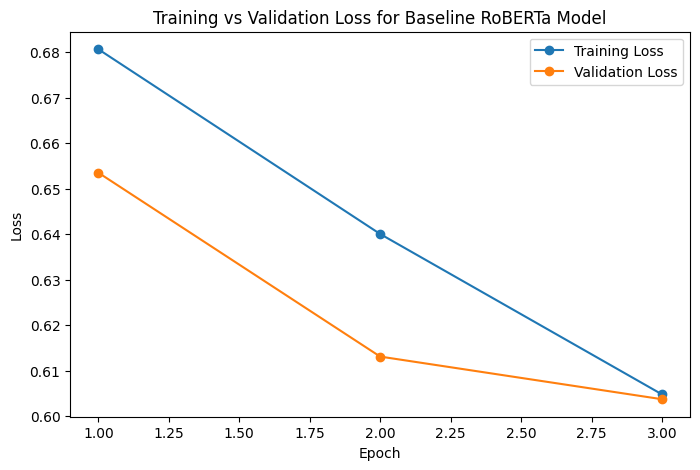

In [8]:
# Training VS Validation loss curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1, len(baseline_train_losses)+1), baseline_train_losses, marker='o', label = 'Training Loss')
plt.plot(range(1, len(baseline_val_losses)+1), baseline_val_losses, marker='o', label = 'Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss for Baseline RoBERTa Model')
plt.legend()
plt.savefig('baseline_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

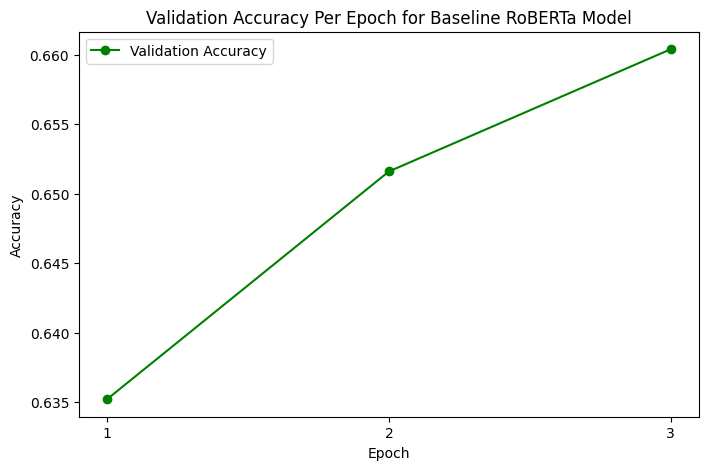

In [9]:
# Validation Accuracy Per Epoch
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1, len(baseline_val_accs)+1), baseline_val_accs, marker='o', color='green', label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy Per Epoch for Baseline RoBERTa Model')
plt.xticks(range(1, len(baseline_val_accs)+1))
plt.legend()
plt.savefig('baseline_val_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

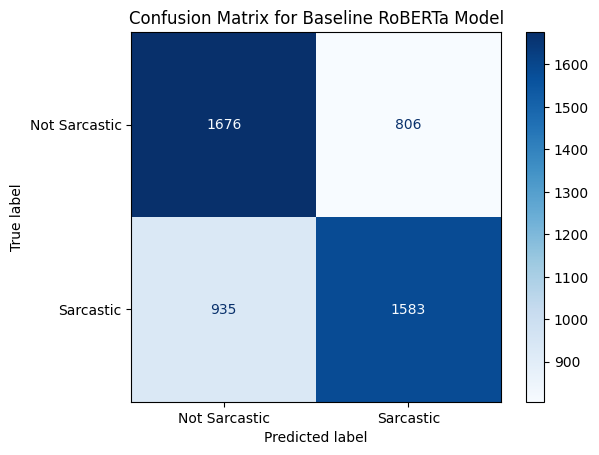

In [10]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(baseline_labels, baseline_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Sarcastic', 'Sarcastic'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix for Baseline RoBERTa Model')
plt.savefig('baseline_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Training and testing with RoBERTa model WITH punctuation features

In [10]:
train_loader, val_loader, test_loader = loaders("/content/drive/MyDrive/merged_data.csv", use_features=True)

advanced_model = RobertaWithFeatures(num_extra_features=0).to(device)
advanced_model.float()

for name, param in advanced_model.roberta.named_parameters():
    if "embeddings" in name:
        param.requires_grad = False


print("Training Loop for Advanced Model")
advanced_model, train_losses, val_losses, val_accs = train_model(
    advanced_model, train_loader, val_loader, model_name="full"
)


print("Evaluation of Advanced Model")
loss, acc, labels, preds = evaluate_model(advanced_model, test_loader)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training Loop for Advanced Model
Starting training: full

  -> Batch 0/1094...
  -> Batch 50/1094...
  -> Batch 100/1094...
  -> Batch 150/1094...
  -> Batch 200/1094...
  -> Batch 250/1094...
  -> Batch 300/1094...
  -> Batch 350/1094...
  -> Batch 400/1094...
  -> Batch 450/1094...
  -> Batch 500/1094...
  -> Batch 550/1094...
  -> Batch 600/1094...
  -> Batch 650/1094...
  -> Batch 700/1094...
  -> Batch 750/1094...
  -> Batch 800/1094...
  -> Batch 850/1094...
  -> Batch 900/1094...
  -> Batch 950/1094...
  -> Batch 1000/1094...
  -> Batch 1050/1094...
*** Epoch 1/3 | Train Loss: 0.6831 ***

*** Epoch 1/3 | Val Loss: 0.6442 | Val Acc: 0.6276 ***

  -> Improved, model saved.

  -> Batch 0/1094...
  -> Batch 50/1094...
  -> Batch 100/1094...
  -> Batch 150/1094...
  -> Batch 200/1094...
  -> Batch 250/1094...
  -> Batch 300/1094...
  -> Batch 350/1094...
  -> Batch 400/1094...
  -> Batch 450/1094...
  -> Batch 500/1094...
  -> Batch 550/1094...
  -> Batch 600/1094...
  -> Batch 650/1

# Graphs for baseline RoBERTa Model WITH Punctuation Features

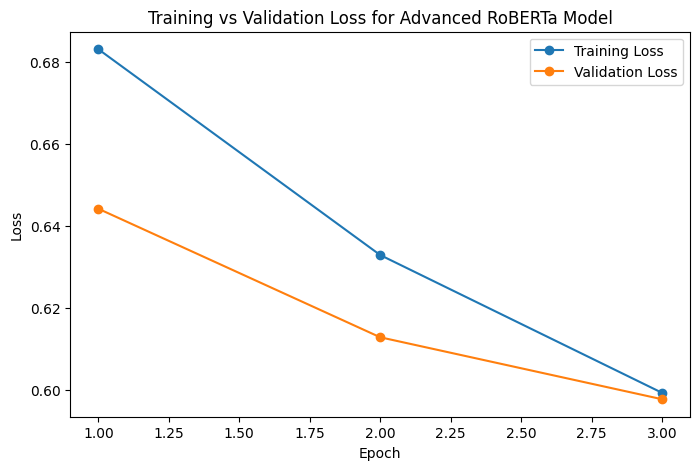

In [11]:
# Training VS Validation loss curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1, len(train_losses)+1), train_losses, marker='o', label = 'Training Loss')
plt.plot(range(1, len(val_losses)+1), val_losses, marker='o', label = 'Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss for Advanced RoBERTa Model')
plt.legend()
plt.savefig('advanced_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

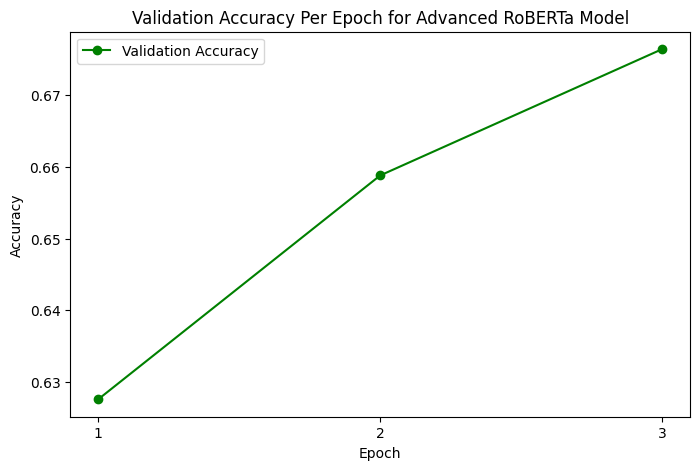

In [12]:
# Validation Accuracy Per Epoch
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1, len(val_accs)+1), val_accs, marker='o', color='green', label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy Per Epoch for Advanced RoBERTa Model')
plt.xticks(range(1, len(val_accs)+1))
plt.legend()
plt.savefig('advanced_val_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

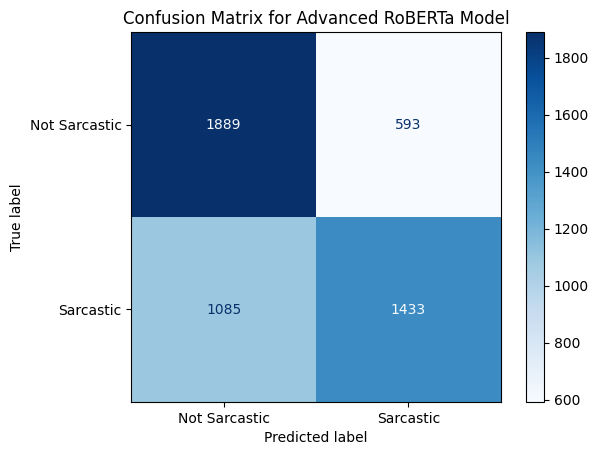

In [13]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(labels, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Sarcastic', 'Sarcastic'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix for Advanced RoBERTa Model')
plt.savefig('advanced_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

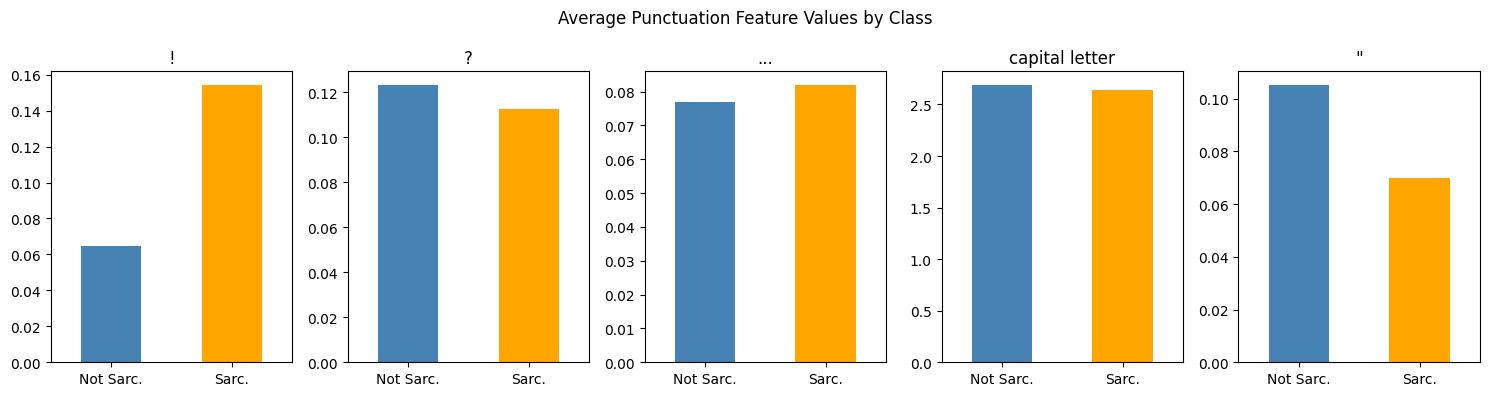

In [17]:
import seaborn as sns
import re

df = pd.read_csv("/content/drive/MyDrive/merged_data.csv").sample(n=25000, random_state=42).reset_index(drop=True)

# Extract punctuation counts from text
df['!']              = df['comment'].astype(str).apply(lambda x: x.count('!'))
df['?']              = df['comment'].astype(str).apply(lambda x: x.count('?'))
df['...']            = df['comment'].astype(str).apply(lambda x: x.count('...'))
df['capital letter'] = df['comment'].astype(str).apply(lambda x: sum(1 for c in x if c.isupper()))
df['"']              = df['comment'].astype(str).apply(lambda x: x.count('"'))

# Plot
fig, axes = plt.subplots(1, 5, figsize=(15, 4))
feature_cols = ["!", "?", "...", "capital letter", '"']

for i, col in enumerate(feature_cols):
    df.groupby('label')[col].mean().plot(kind='bar', ax=axes[i], color=['steelblue', 'orange'])
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_xticklabels(['Not Sarc.', 'Sarc.'], rotation=0)

plt.suptitle('Average Punctuation Feature Values by Class')
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()